In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

# Set visualization style
sns.set_theme(style="whitegrid")

# Authenticate with GCP
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/gcp-key.json"

# Replace with your actual GCP Project ID!
PROJECT_ID = "olist-data-pipeline-489511"
DATASET_ID = "olist_analytics"

# Create native BigQuery Client
client = bigquery.Client(project=PROJECT_ID)
print(f"✅ Successfully connected to BigQuery! Project: {client.project}")

✅ Successfully connected to BigQuery! Project: olist-data-pipeline-489511


/home/dsai/miniconda3/envs/olist_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/dsai/miniconda3/envs/olist_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


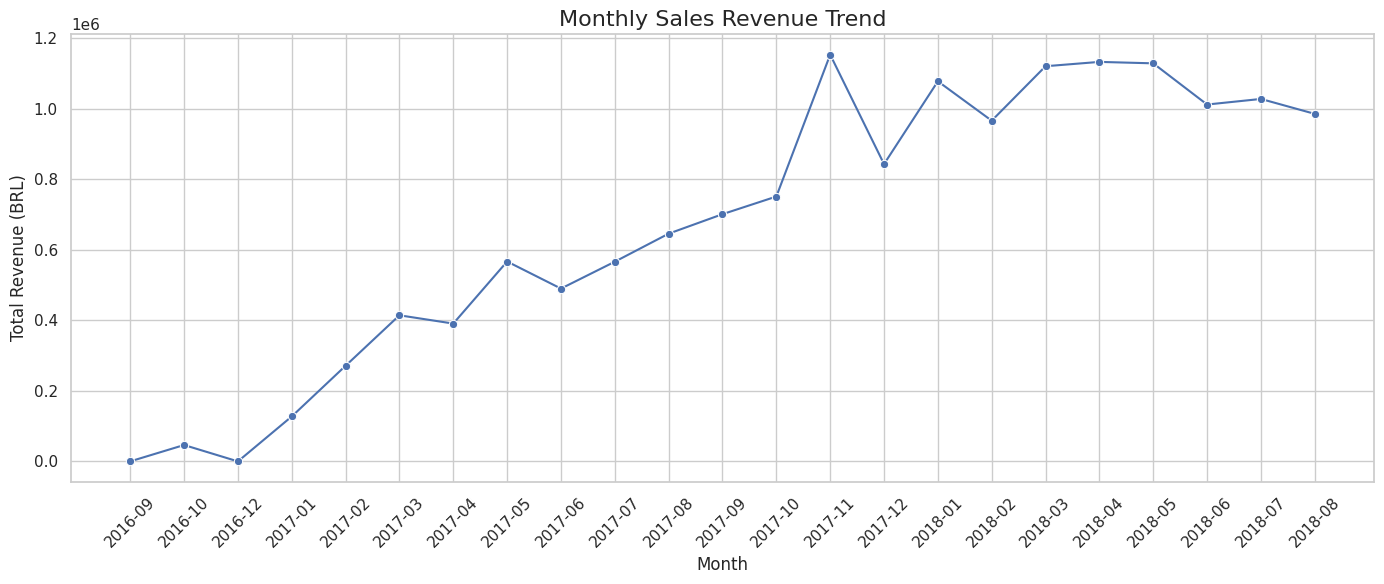

In [2]:
# Query: Monthly Sales Trends (Notice the full table paths!)
query_trends = f"""
    SELECT 
        d.year_month,
        SUM(f.total_sale_amount) AS total_revenue,
        COUNT(DISTINCT f.order_id) AS total_orders
    FROM `{PROJECT_ID}.{DATASET_ID}.fact_sales` f
    JOIN `{PROJECT_ID}.{DATASET_ID}.dim_date` d ON f.date_id = d.date_id
    GROUP BY d.year_month
    ORDER BY d.year_month
"""

# Fetch data directly using Google's client (Bypasses SQLAlchemy entirely)
df_trends = client.query(query_trends).to_dataframe()

# Plotting the trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trends, x='year_month', y='total_revenue', marker='o', color='b')
plt.title('Monthly Sales Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3893/3307927151.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_products, x='total_revenue', y='product_category', palette='viridis')


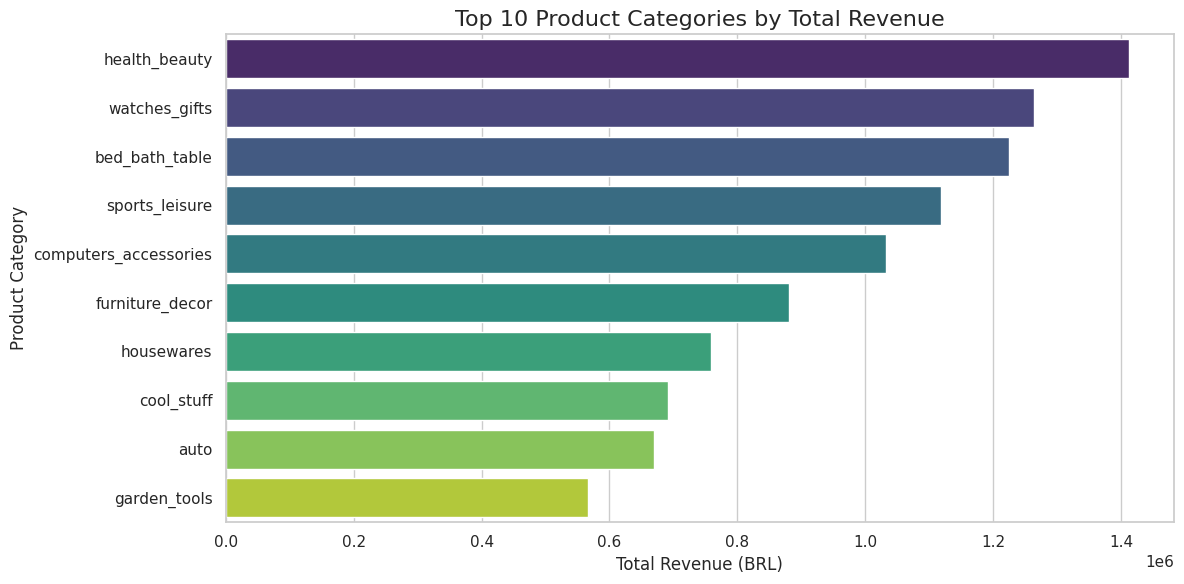

In [3]:
# Query: Top 10 Product Categories by Revenue
query_products = f"""
    SELECT 
        p.category_name_english AS product_category,
        SUM(f.total_sale_amount) AS total_revenue
    FROM `{PROJECT_ID}.{DATASET_ID}.fact_sales` f
    JOIN `{PROJECT_ID}.{DATASET_ID}.dim_product` p ON f.product_id = p.product_id
    WHERE p.category_name_english != 'unknown'
    GROUP BY 1
    ORDER BY 2 DESC
    LIMIT 10
"""

# Fetch data directly using Google's client
df_products = client.query(query_products).to_dataframe()

# Plotting the top products
plt.figure(figsize=(12, 6))
sns.barplot(data=df_products, x='total_revenue', y='product_category', palette='viridis')
plt.title('Top 10 Product Categories by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue (BRL)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3893/1334971701.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Customer Count', y='Segment', palette='magma')


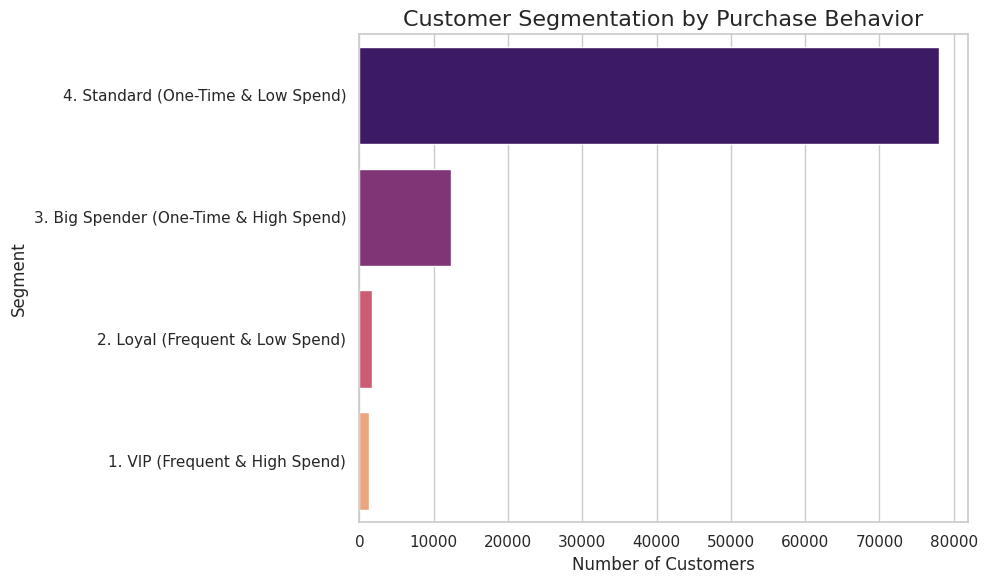

                                  Segment  Customer Count
0      4. Standard (One-Time & Low Spend)           77989
1  3. Big Spender (One-Time & High Spend)           12390
2         2. Loyal (Frequent & Low Spend)            1712
3          1. VIP (Frequent & High Spend)            1267


In [4]:
# Query: Customer Behavior Data
query_customers = f"""
    SELECT 
        c.customer_unique_id,
        c.total_orders_placed,
        MAX(f.customer_lifetime_value) AS clv
    FROM `{PROJECT_ID}.{DATASET_ID}.dim_customer` c
    JOIN `{PROJECT_ID}.{DATASET_ID}.fact_sales` f ON c.customer_unique_id = f.customer_unique_id
    GROUP BY 1, 2
"""

# Fetch data directly using Google's client
df_customers = client.query(query_customers).to_dataframe()

# Define segmentation logic
def segment_customer(row):
    if row['total_orders_placed'] > 1 and row['clv'] > 250:
        return '1. VIP (Frequent & High Spend)'
    elif row['total_orders_placed'] > 1:
        return '2. Loyal (Frequent & Low Spend)'
    elif row['clv'] > 250:
        return '3. Big Spender (One-Time & High Spend)'
    else:
        return '4. Standard (One-Time & Low Spend)'

# Apply the segmentation
df_customers['Segment'] = df_customers.apply(segment_customer, axis=1)

# Calculate segment sizes
segment_counts = df_customers['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']

# Plotting the segments
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_counts, x='Customer Count', y='Segment', palette='magma')
plt.title('Customer Segmentation by Purchase Behavior', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Segment', fontsize=12)
plt.tight_layout()
plt.show()

# Display the exact numbers below the chart
print(segment_counts)